# Análisis y Predicción del Tráfico Portuario Marítimo en Colombia
**Examen Final — Curso 709718**  
**Universidad Cooperativa de Colombia**  
**Integrantes:** Juan David Arboleda Molina — Juan Diego Nieto Cáceres  
**Herramienta:** Python / Jupyter Notebook

## 1. Importar librerías

In [1]:
import pandas as pd
!pip install scikit-learn
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

# Para que las figuras salgan dentro del notebook
%matplotlib inline
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'

print('Librerías cargadas correctamente.')

Librerías cargadas correctamente.


## 2. Carga y limpieza de datos

In [2]:
import os, glob

# Busca el CSV automaticamente donde este
posibles = (
    glob.glob("*.csv") +
    glob.glob("../datos/datos_originales/*.csv") +
    glob.glob("../datos/*.csv") +
    glob.glob("/workspaces/**/*Trafico*.csv", recursive=True)
)

ARCHIVO = next((f for f in posibles if "Trafico" in f or "trafico" in f.lower()), None)

if ARCHIVO:
    print(f"CSV encontrado: {ARCHIVO}")
else:
    raise FileNotFoundError("No se encontro el CSV. Ponlo en la misma carpeta que el notebook.")

df = pd.read_csv(ARCHIVO)
df.columns = df.columns.str.strip()
print(f"Registros cargados: {len(df)} | Columnas: {len(df.columns)}")
print("Columnas:", df.columns.tolist())

CSV encontrado: Trafico_Portuario_Maritimo_En_Colombia_20260511.csv
Registros cargados: 9310 | Columnas: 14
Columnas: ['ZONA PORTUARIA', 'SOCIEDAD PORTUARIA', 'TIPO DE SERVICIO', 'TIPO DE CARGA', 'EXPORTACION', 'IMPORTACIÓN', 'TRANSBORDO', 'TRANSITO INTERNACIONAL', 'FLUVIAL', 'CABOTAJE', 'MOVILIZACIONES A BORDO', 'TRANSITORIA', 'AÑO VIGENCIA', 'MES VIGENCIA']


In [3]:
# -------------------------------------------------------
# PROBLEMA 1: columnas numéricas guardadas como texto
# con coma como separador de miles → '71,867' debe ser 71867
# -------------------------------------------------------
col_num = [
    'EXPORTACION', 'IMPORTACIÓN', 'TRANSBORDO',
    'TRANSITO INTERNACIONAL', 'FLUVIAL', 'CABOTAJE',
    'MOVILIZACIONES A BORDO', 'TRANSITORIA'
]

for c in col_num:
    df[c] = df[c].astype(str).str.replace(',', '').str.strip().astype(float)

# PROBLEMA 2: año guardado como texto '2,023' → 2023
df['AÑO VIGENCIA'] = df['AÑO VIGENCIA'].astype(str).str.replace(',', '').str.strip().astype(int)

# PROBLEMA 3: revisar duplicados
n_dup = df.duplicated().sum()
print(f'Duplicados encontrados: {n_dup}')

# PROBLEMA 4: nulos
print(f'Nulos por columna:')
print(df.isnull().sum())

Duplicados encontrados: 0
Nulos por columna:
ZONA PORTUARIA            0
SOCIEDAD PORTUARIA        0
TIPO DE SERVICIO          0
TIPO DE CARGA             0
EXPORTACION               0
IMPORTACIÓN               0
TRANSBORDO                0
TRANSITO INTERNACIONAL    0
FLUVIAL                   0
CABOTAJE                  0
MOVILIZACIONES A BORDO    0
TRANSITORIA               0
AÑO VIGENCIA              0
MES VIGENCIA              0
dtype: int64


In [4]:
# -------------------------------------------------------
# VARIABLES DERIVADAS
# -------------------------------------------------------

# VD1: Variable objetivo — total movilizado
df['TOTAL_MOVILIZADO'] = df[col_num].sum(axis=1)

# VD2: Balance exportación - importación
df['BALANCE_EXP_IMP'] = df['EXPORTACION'] - df['IMPORTACIÓN']

# VD3: Indicador año incompleto
df['ANO_INCOMPLETO'] = (df['AÑO VIGENCIA'] == 2026).astype(int)

# VD4: Flujos menores
df['FLUJOS_MENORES'] = df['TRANSBORDO'] + df['FLUVIAL'] + df['CABOTAJE']

# Resumen de TOTAL_MOVILIZADO
print('=== TOTAL_MOVILIZADO ===')
print(df['TOTAL_MOVILIZADO'].describe().round(0))
print(f'\nRegistros con total = 0: {(df["TOTAL_MOVILIZADO"] == 0).sum()}')
print(f'Años únicos: {sorted(df["AÑO VIGENCIA"].unique())}')

=== TOTAL_MOVILIZADO ===
count       9310.0
mean      158245.0
std       403588.0
min            0.0
25%         6516.0
50%        28413.0
75%        94702.0
max      3418965.0
Name: TOTAL_MOVILIZADO, dtype: float64

Registros con total = 0: 54
Años únicos: [np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025), np.int64(2026)]


## 3. Figura 1 — Calidad de datos

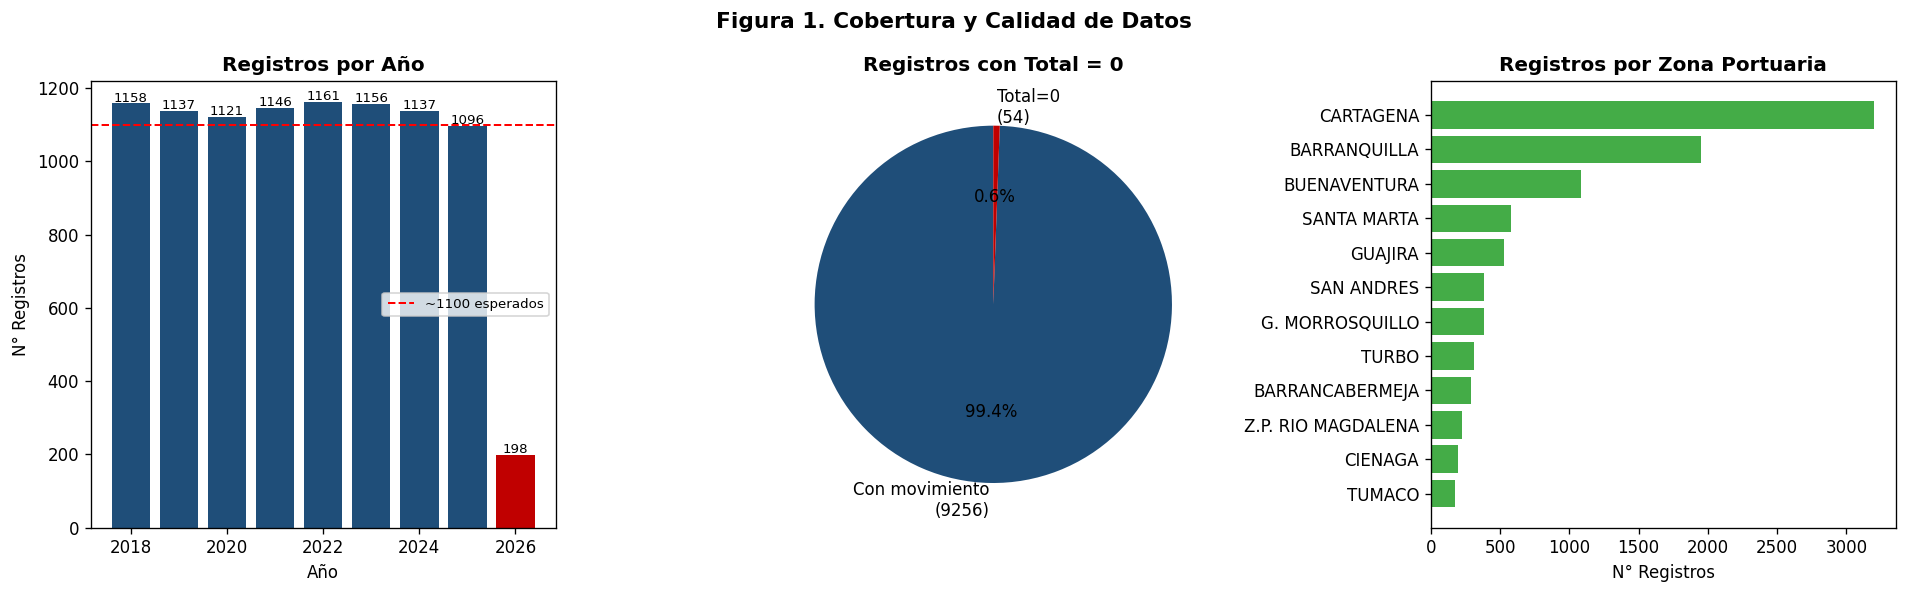

Figura 1 guardada.


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Figura 1. Cobertura y Calidad de Datos', fontsize=13, fontweight='bold')

# 1a: Registros por año
reg_ano = df.groupby('AÑO VIGENCIA').size()
colores = ['#c00000' if yr == 2026 else '#1f4e79' for yr in reg_ano.index]
axes[0].bar(reg_ano.index, reg_ano.values, color=colores)
axes[0].axhline(1100, color='red', linestyle='--', linewidth=1.2, label='~1100 esperados')
axes[0].set_title('Registros por Año', fontweight='bold')
axes[0].set_xlabel('Año'); axes[0].set_ylabel('N° Registros')
axes[0].legend(fontsize=8)
for yr, v in reg_ano.items():
    axes[0].text(yr, v + 5, str(v), ha='center', fontsize=8)

# 1b: Ceros vs con dato
ceros = (df['TOTAL_MOVILIZADO'] == 0).sum()
axes[1].pie(
    [len(df) - ceros, ceros],
    labels=[f'Con movimiento\n({len(df)-ceros})', f'Total=0\n({ceros})'],
    colors=['#1f4e79', '#c00000'],
    autopct='%1.1f%%', startangle=90
)
axes[1].set_title('Registros con Total = 0', fontweight='bold')

# 1c: Registros por zona
reg_zona = df.groupby('ZONA PORTUARIA').size().sort_values()
axes[2].barh(reg_zona.index, reg_zona.values, color='#44ac47')
axes[2].set_title('Registros por Zona Portuaria', fontweight='bold')
axes[2].set_xlabel('N° Registros')

plt.tight_layout()
plt.savefig('figura1_calidad_datos.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura 1 guardada.')

## 4. Figura 2 — Evolución temporal

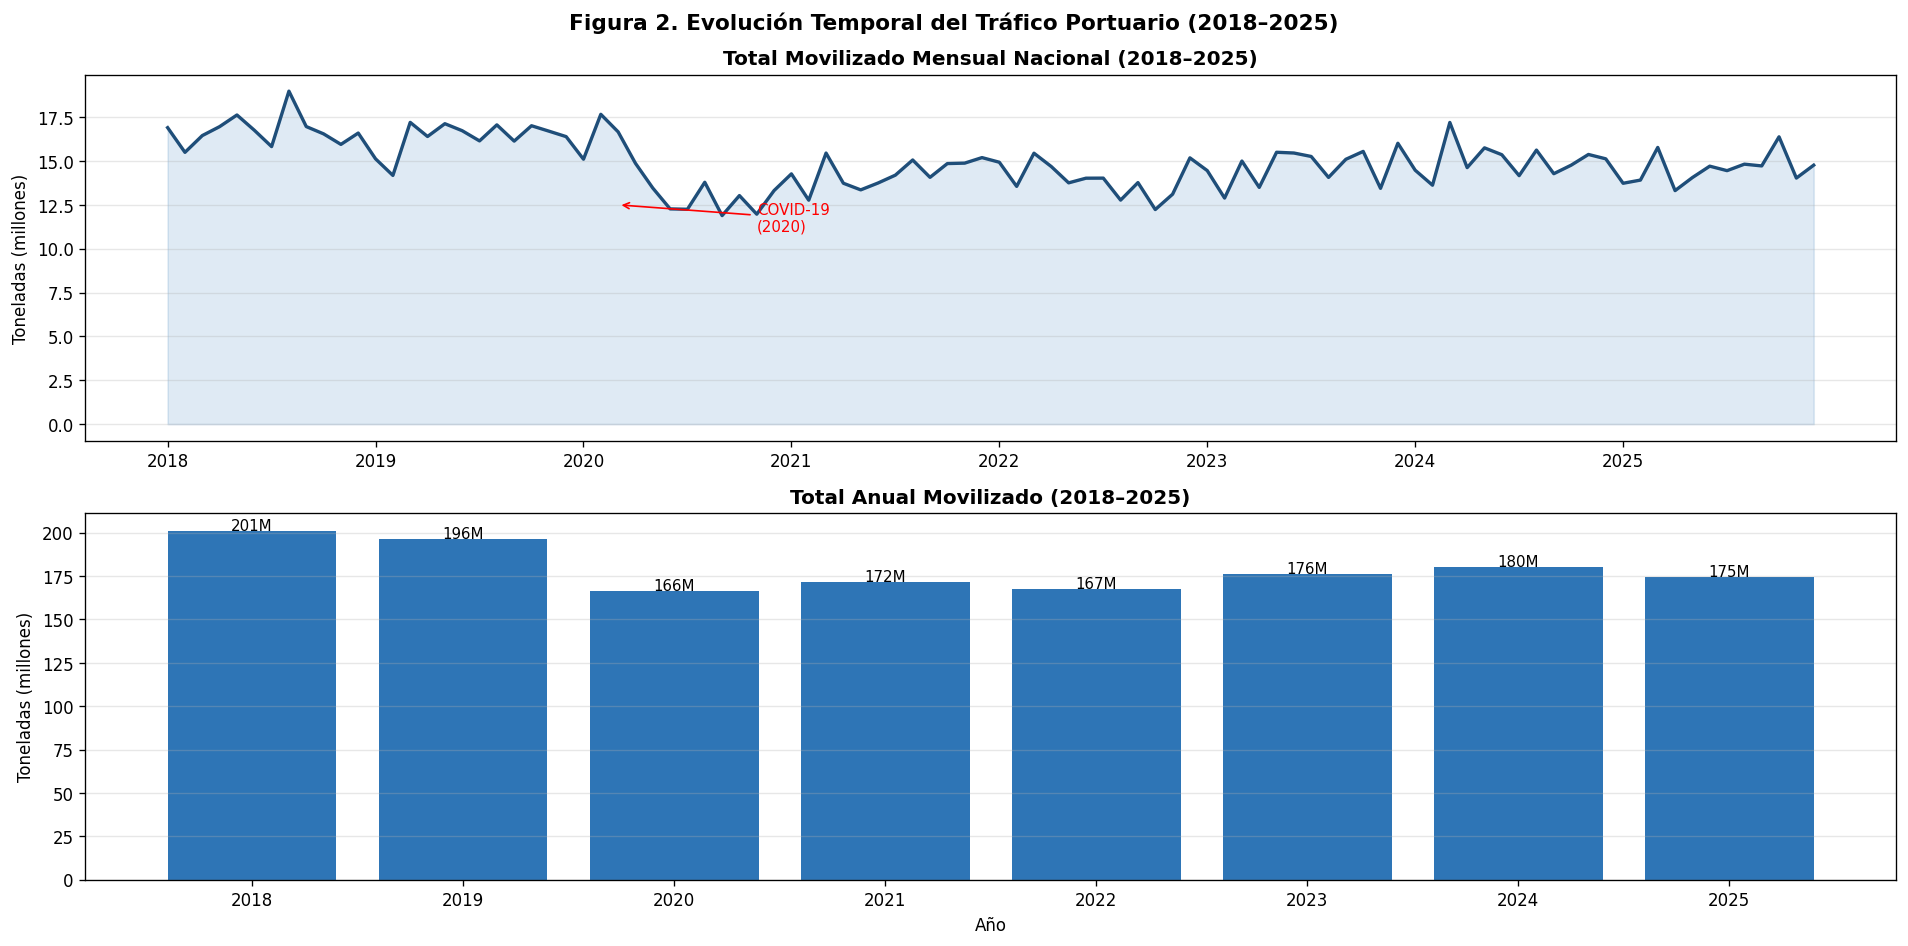

Figura 2 guardada.


In [6]:
df_base = df[df['AÑO VIGENCIA'] < 2026].copy()

# Serie mensual
monthly = df_base.groupby(['AÑO VIGENCIA', 'MES VIGENCIA'])['TOTAL_MOVILIZADO'].sum().reset_index()
monthly['IDX'] = (monthly['AÑO VIGENCIA'] - 2018) * 12 + monthly['MES VIGENCIA']
monthly = monthly.sort_values('IDX')

# Total anual
anual = df_base.groupby('AÑO VIGENCIA')['TOTAL_MOVILIZADO'].sum()

fig, axes = plt.subplots(2, 1, figsize=(16, 8))
fig.suptitle('Figura 2. Evolución Temporal del Tráfico Portuario (2018–2025)', fontsize=13, fontweight='bold')

# Serie mensual
axes[0].plot(monthly['IDX'], monthly['TOTAL_MOVILIZADO']/1e6, color='#1f4e79', linewidth=2)
axes[0].fill_between(monthly['IDX'], monthly['TOTAL_MOVILIZADO']/1e6, alpha=0.15, color='#2e75b6')
axes[0].set_title('Total Movilizado Mensual Nacional (2018–2025)', fontweight='bold')
axes[0].set_ylabel('Toneladas (millones)')
xticks = list(range(1, 97, 12))
axes[0].set_xticks(xticks)
axes[0].set_xticklabels([str(2018 + i) for i in range(len(xticks))])
axes[0].annotate('COVID-19\n(2020)', xy=(27, 12.5), xytext=(35, 11),
                 arrowprops=dict(arrowstyle='->', color='red'), color='red', fontsize=9)
axes[0].grid(axis='y', alpha=0.3)

# Anual
axes[1].bar(anual.index, anual.values/1e6, color='#2e75b6')
axes[1].set_title('Total Anual Movilizado (2018–2025)', fontweight='bold')
axes[1].set_ylabel('Toneladas (millones)'); axes[1].set_xlabel('Año')
for yr, v in anual.items():
    axes[1].text(yr, v/1e6 + 0.5, f'{v/1e6:.0f}M', ha='center', fontsize=9)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('figura2_serie_temporal.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura 2 guardada.')

## 5. Figura 3 — Comparación por grupos

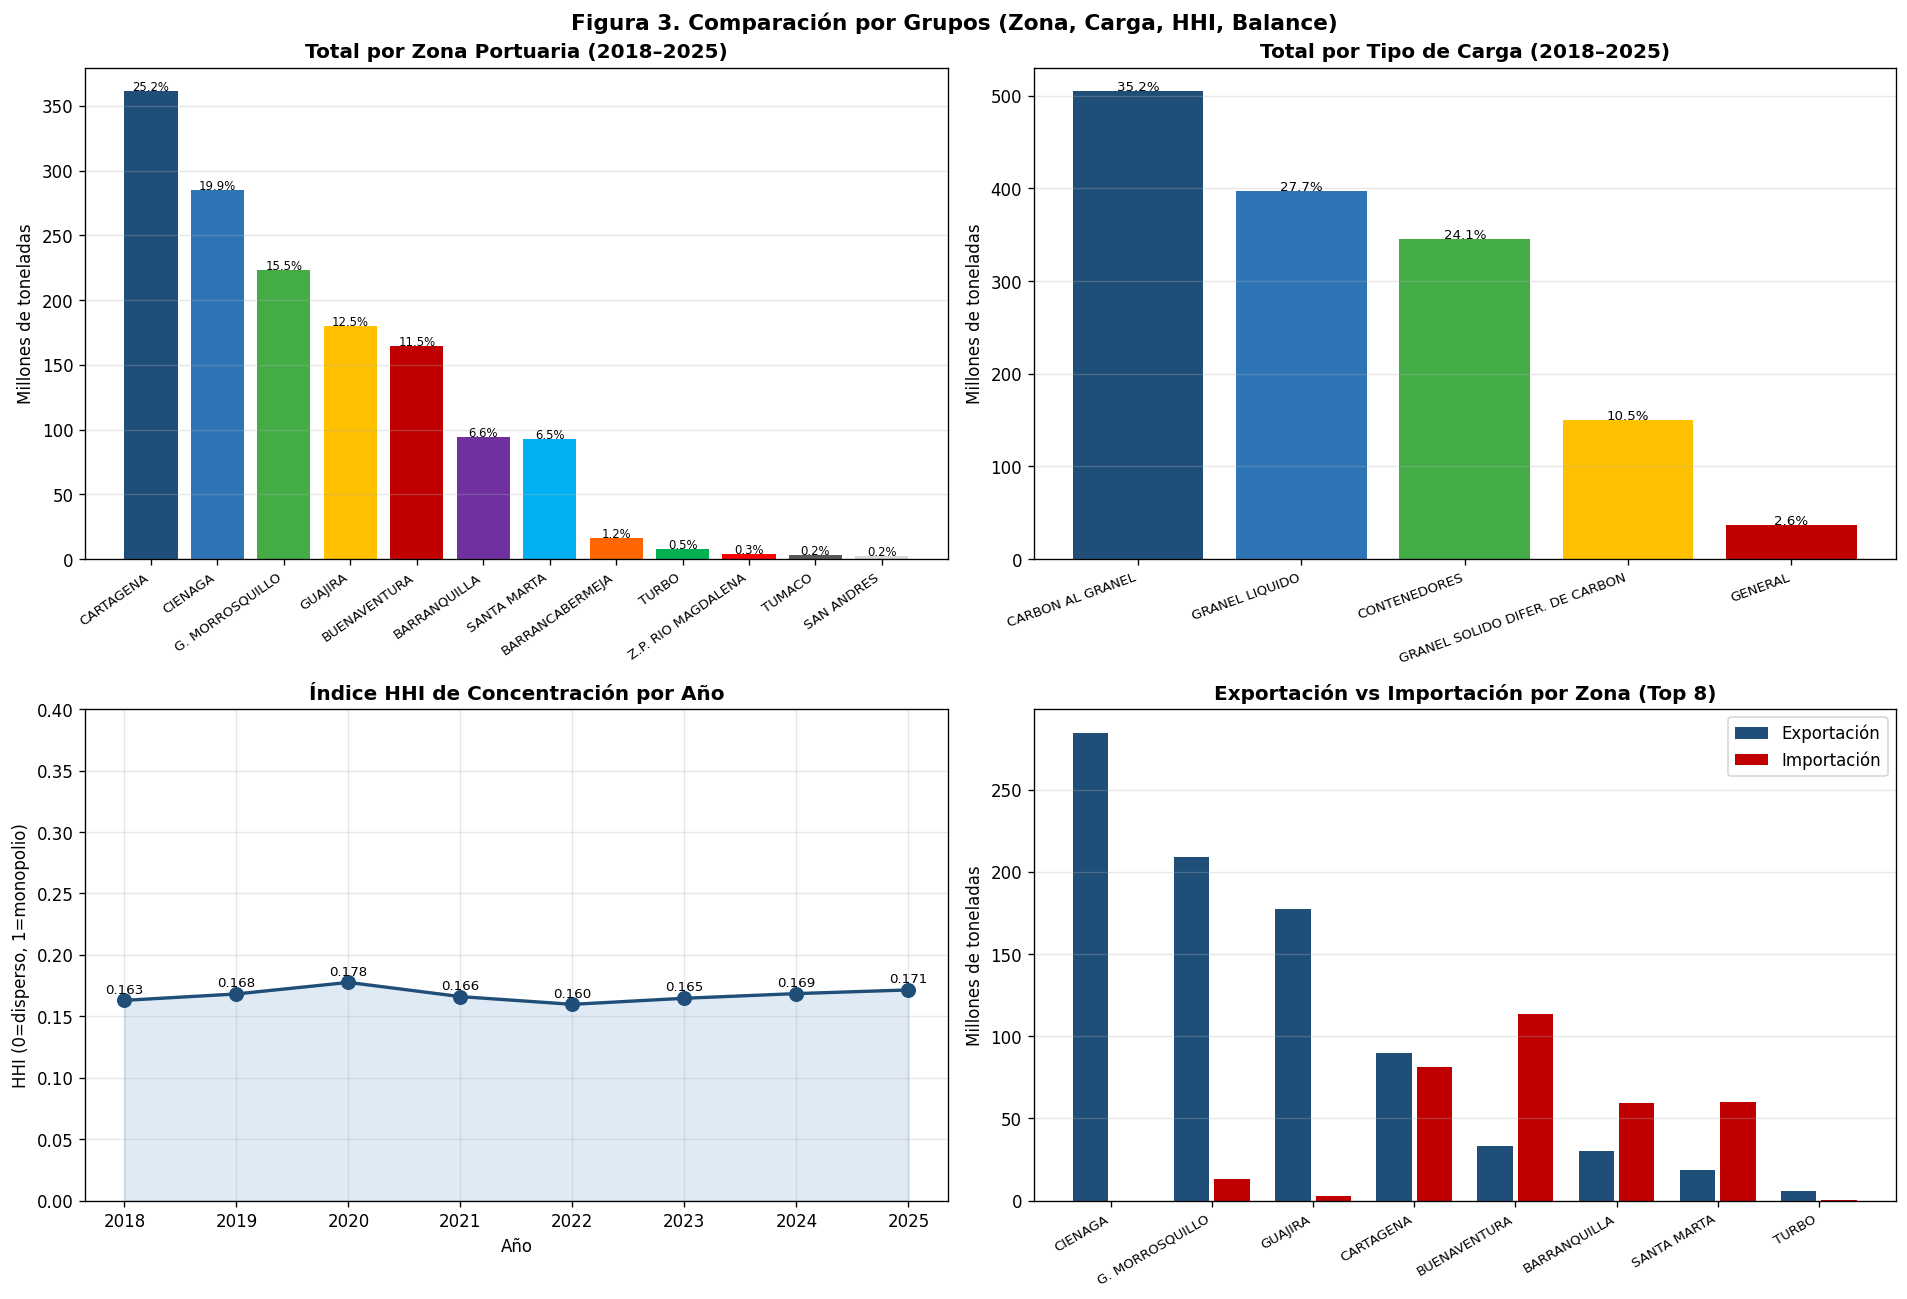

Figura 3 guardada.


In [7]:
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle('Figura 3. Comparación por Grupos (Zona, Carga, HHI, Balance)', fontsize=13, fontweight='bold')

COLS = ['#1f4e79','#2e75b6','#44ac47','#ffc000','#c00000','#7030a0','#00b0f0','#ff6600','#00b050','#ff0000','#595959','#d9d9d9']

# 3a: Total por zona
zona_t = df_base.groupby('ZONA PORTUARIA')['TOTAL_MOVILIZADO'].sum().sort_values(ascending=False) / 1e6
axes[0,0].bar(range(len(zona_t)), zona_t.values, color=COLS[:len(zona_t)])
axes[0,0].set_xticks(range(len(zona_t)))
axes[0,0].set_xticklabels(zona_t.index, rotation=35, ha='right', fontsize=8)
axes[0,0].set_title('Total por Zona Portuaria (2018–2025)', fontweight='bold')
axes[0,0].set_ylabel('Millones de toneladas')
for i, v in enumerate(zona_t.values):
    axes[0,0].text(i, v + 0.5, f'{v/zona_t.sum()*100:.1f}%', ha='center', fontsize=7)
axes[0,0].grid(axis='y', alpha=0.3)

# 3b: Por tipo de carga
carga_t = df_base.groupby('TIPO DE CARGA')['TOTAL_MOVILIZADO'].sum().sort_values(ascending=False) / 1e6
axes[0,1].bar(range(len(carga_t)), carga_t.values, color=COLS[:len(carga_t)])
axes[0,1].set_xticks(range(len(carga_t)))
axes[0,1].set_xticklabels(carga_t.index, rotation=20, ha='right', fontsize=8)
axes[0,1].set_title('Total por Tipo de Carga (2018–2025)', fontweight='bold')
axes[0,1].set_ylabel('Millones de toneladas')
for i, v in enumerate(carga_t.values):
    axes[0,1].text(i, v + 0.5, f'{v/carga_t.sum()*100:.1f}%', ha='center', fontsize=8)
axes[0,1].grid(axis='y', alpha=0.3)

# 3c: HHI por año
anos = sorted(df_base['AÑO VIGENCIA'].unique())
hhi_vals = []
for yr in anos:
    s = df[df['AÑO VIGENCIA']==yr].groupby('ZONA PORTUARIA')['TOTAL_MOVILIZADO'].sum()
    sh = s / s.sum()
    hhi_vals.append((sh**2).sum())
axes[1,0].plot(anos, hhi_vals, marker='o', color='#1f4e79', linewidth=2, markersize=8)
axes[1,0].fill_between(anos, hhi_vals, alpha=0.15, color='#2e75b6')
axes[1,0].set_title('Índice HHI de Concentración por Año', fontweight='bold')
axes[1,0].set_ylabel('HHI (0=disperso, 1=monopolio)'); axes[1,0].set_xlabel('Año')
axes[1,0].set_ylim(0, 0.4); axes[1,0].grid(alpha=0.3)
for yr, hhi in zip(anos, hhi_vals):
    axes[1,0].text(yr, hhi + 0.006, f'{hhi:.3f}', ha='center', fontsize=8)

# 3d: Export vs Import top 8 zonas
bal = df_base.groupby('ZONA PORTUARIA')[['EXPORTACION', 'IMPORTACIÓN']].sum()
bal = bal.sort_values('EXPORTACION', ascending=False).head(8)
x = np.arange(len(bal))
axes[1,1].bar(x - 0.2, bal['EXPORTACION']/1e6, 0.35, label='Exportación', color='#1f4e79')
axes[1,1].bar(x + 0.2, bal['IMPORTACIÓN']/1e6, 0.35, label='Importación', color='#c00000')
axes[1,1].set_xticks(x)
axes[1,1].set_xticklabels(bal.index, rotation=30, ha='right', fontsize=8)
axes[1,1].set_title('Exportación vs Importación por Zona (Top 8)', fontweight='bold')
axes[1,1].set_ylabel('Millones de toneladas')
axes[1,1].legend(); axes[1,1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('figura3_comparacion_grupos.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura 3 guardada.')

## 6. Modelado — Partición temporal y 4 configuraciones

In [8]:
# Agregar a nivel zona × carga × mes × año
agg = df_base.groupby(
    ['AÑO VIGENCIA', 'MES VIGENCIA', 'ZONA PORTUARIA', 'TIPO DE CARGA', 'TIPO DE SERVICIO']
)['TOTAL_MOVILIZADO'].sum().reset_index()
agg = agg[agg['TOTAL_MOVILIZADO'] > 0].copy()

# Partición temporal: Train 2018-2023 | Test 2024-2025
train = agg[agg['AÑO VIGENCIA'] <= 2023].copy()
test  = agg[agg['AÑO VIGENCIA'] >= 2024].copy()

print(f'Train: {len(train)} registros (2018–2023)')
print(f'Test:  {len(test)} registros (2024–2025)')

def metricas(y_true, y_pred, label):
    y_true = np.array(y_true); y_pred = np.array(y_pred)
    mae  = np.abs(y_true - y_pred).mean()
    rmse = np.sqrt(((y_true - y_pred)**2).mean())
    nrmse = rmse / y_true.mean() * 100
    ss_res = ((y_true - y_pred)**2).sum()
    ss_tot = ((y_true - y_true.mean())**2).sum()
    r2 = 1 - ss_res / ss_tot
    print(f'{label}: MAE={mae/1e3:.1f}k  RMSE={rmse/1e3:.1f}k  nRMSE={nrmse:.1f}%  R²={r2:.3f}')
    return mae, rmse, nrmse, r2

Train: 3568 registros (2018–2023)
Test:  1135 registros (2024–2025)


In [9]:
# -------------------------------------------------------
# MODELO 0: Media histórica por Zona × Carga (línea base)
# -------------------------------------------------------
media_zc = train.groupby(['ZONA PORTUARIA', 'TIPO DE CARGA'])['TOTAL_MOVILIZADO'].mean()
media_global = train['TOTAL_MOVILIZADO'].mean()

def predecir_m0(row):
    key = (row['ZONA PORTUARIA'], row['TIPO DE CARGA'])
    return media_zc.get(key, media_global)

pred_m0 = test.apply(predecir_m0, axis=1).values
y_test   = test['TOTAL_MOVILIZADO'].values
y_train  = train['TOTAL_MOVILIZADO'].values
pred_m0_tr = train.apply(predecir_m0, axis=1).values

print('=== COMPARACIÓN DE MODELOS (conjunto de prueba 2024–2025) ===')
MAE0, RMSE0, nRMSE0, R2_0 = metricas(y_test, pred_m0, 'M0 — Media Zona×Carga   ')
MAE0_tr, _, _, R2_0_tr = metricas(y_train, pred_m0_tr, 'M0 — TRAIN              ')

=== COMPARACIÓN DE MODELOS (conjunto de prueba 2024–2025) ===
M0 — Media Zona×Carga   : MAE=142.0k  RMSE=319.7k  nRMSE=102.2%  R²=0.692
M0 — TRAIN              : MAE=130.7k  RMSE=304.7k  nRMSE=100.8%  R²=0.727


In [10]:
# -------------------------------------------------------
# MODELOS 1, 2, 3: Regresión con distintas configuraciones
# -------------------------------------------------------
def codificar(df_in, encoders=None, fit=False):
    d = df_in.copy()
    d['SIN'] = np.sin(2 * np.pi * d['MES VIGENCIA'] / 12)
    d['COS'] = np.cos(2 * np.pi * d['MES VIGENCIA'] / 12)
    cols_cat = ['ZONA PORTUARIA', 'TIPO DE CARGA', 'TIPO DE SERVICIO']
    if fit:
        encoders = {c: LabelEncoder().fit(d[c]) for c in cols_cat}
    for c in cols_cat:
        d[c + '_ENC'] = encoders[c].transform(d[c])
    return d, encoders

tr_f, enc = codificar(train, fit=True)
te_f, _   = codificar(test, encoders=enc)

feats_base = ['AÑO VIGENCIA', 'SIN', 'COS', 'ZONA PORTUARIA_ENC', 'TIPO DE CARGA_ENC', 'TIPO DE SERVICIO_ENC']

# M1: Regresión lineal
m1 = LinearRegression().fit(tr_f[feats_base], y_train)
pred_m1 = np.maximum(m1.predict(te_f[feats_base]), 0)
MAE1, RMSE1, nRMSE1, R2_1 = metricas(y_test, pred_m1, 'M1 — Reg. Lineal        ')

# M2: Regresión con interacción zona×carga
tr_f['INTER'] = tr_f['ZONA PORTUARIA_ENC'] * tr_f['TIPO DE CARGA_ENC']
te_f['INTER'] = te_f['ZONA PORTUARIA_ENC'] * te_f['TIPO DE CARGA_ENC']
feats_inter = feats_base + ['INTER']
m2 = LinearRegression().fit(tr_f[feats_inter], y_train)
pred_m2 = np.maximum(m2.predict(te_f[feats_inter]), 0)
MAE2, RMSE2, nRMSE2, R2_2 = metricas(y_test, pred_m2, 'M2 — Lineal+Interacción ')

# M3: Media solo por zona
media_z = train.groupby('ZONA PORTUARIA')['TOTAL_MOVILIZADO'].mean()
pred_m3 = test['ZONA PORTUARIA'].map(media_z).fillna(media_global).values
MAE3, RMSE3, nRMSE3, R2_3 = metricas(y_test, pred_m3, 'M3 — Media solo Zona    ')

M1 — Reg. Lineal        : MAE=362.2k  RMSE=547.1k  nRMSE=174.9%  R²=0.100
M2 — Lineal+Interacción : MAE=358.7k  RMSE=545.7k  nRMSE=174.5%  R²=0.104
M3 — Media solo Zona    : MAE=297.5k  RMSE=513.2k  nRMSE=164.1%  R²=0.208


In [11]:
# Tabla resumen
resumen = pd.DataFrame({
    'Modelo': ['M0 — Media Zona×Carga', 'M1 — Reg. Lineal', 'M2 — Lineal+Interacción', 'M3 — Media solo Zona'],
    'MAE (miles ton)': [MAE0/1e3, MAE1/1e3, MAE2/1e3, MAE3/1e3],
    'RMSE (miles ton)': [RMSE0/1e3, RMSE1/1e3, RMSE2/1e3, RMSE3/1e3],
    'nRMSE (%)': [nRMSE0, nRMSE1, nRMSE2, nRMSE3],
    'R²': [R2_0, R2_1, R2_2, R2_3]
}).round(3)

resumen.to_csv('metricas_modelos.csv', index=False)
print('Tabla guardada como metricas_modelos.csv')
resumen

Tabla guardada como metricas_modelos.csv


,Modelo,MAE (miles ton),RMSE (miles ton),nRMSE (%),R²
0,M0 — Media Zona×Carga,142.028,319.702,102.223,0.692
1,M1 — Reg. Lineal,362.245,547.085,174.927,0.100
2,M2 — Lineal+Interacción,358.671,545.679,174.477,0.104
3,M3 — Media solo Zona,297.455,513.163,164.081,0.208


## 7. Figura 4 — Observado vs Predicho

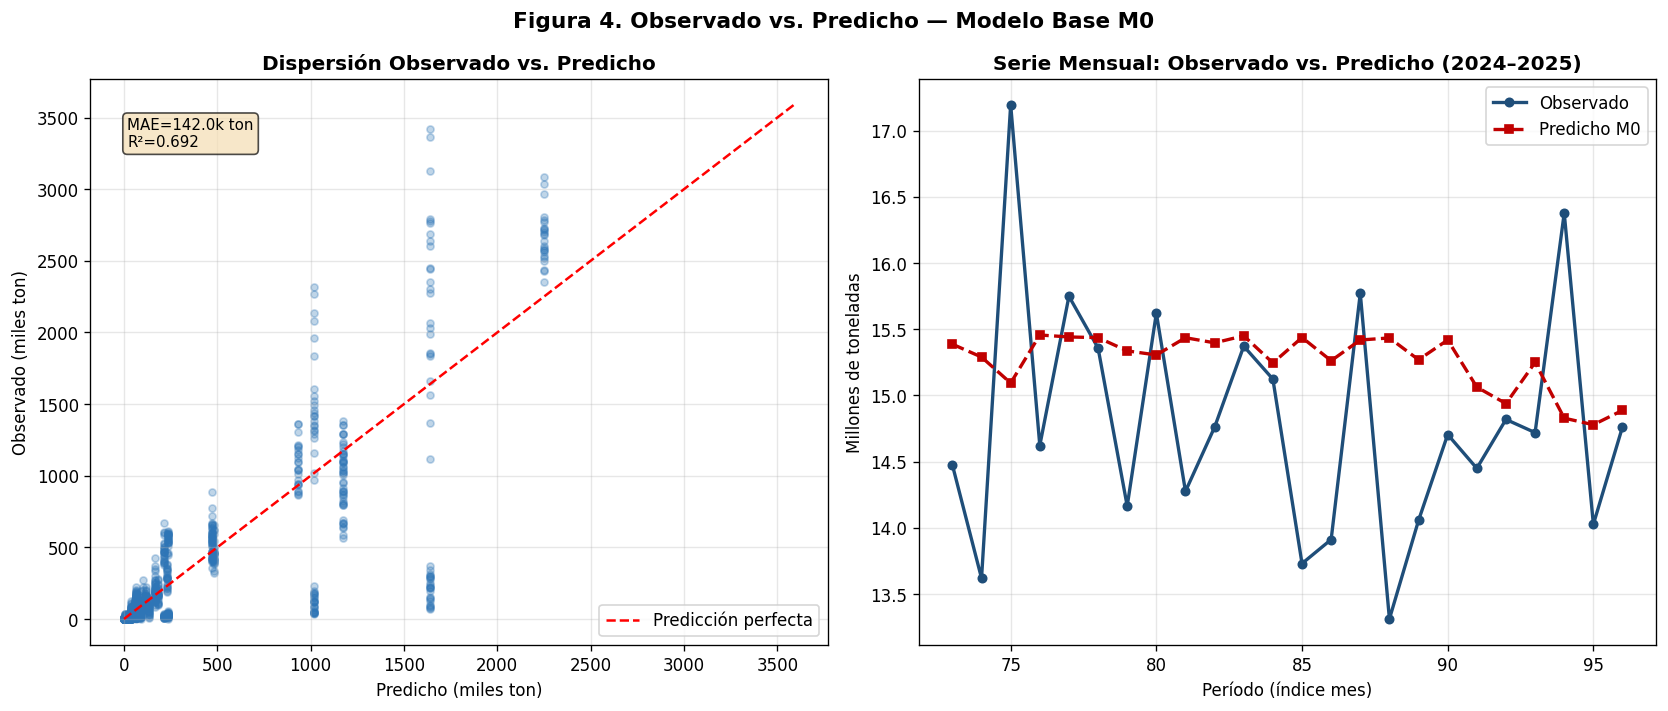

Figura 4 guardada.


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Figura 4. Observado vs. Predicho — Modelo Base M0', fontsize=13, fontweight='bold')

# Dispersión
axes[0].scatter(pred_m0/1e3, y_test/1e3, alpha=0.3, s=18, color='#2e75b6')
lim = max(pred_m0.max(), y_test.max()) / 1e3 * 1.05
axes[0].plot([0, lim], [0, lim], 'r--', linewidth=1.5, label='Predicción perfecta')
axes[0].set_xlabel('Predicho (miles ton)'); axes[0].set_ylabel('Observado (miles ton)')
axes[0].set_title('Dispersión Observado vs. Predicho', fontweight='bold')
axes[0].legend(); axes[0].grid(alpha=0.3)
axes[0].text(0.05, 0.88, f'MAE={MAE0/1e3:.1f}k ton\nR²={R2_0:.3f}',
             transform=axes[0].transAxes,
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7), fontsize=9)

# Serie mensual
test2 = test.copy()
test2['PRED'] = pred_m0
test2['IDX'] = (test2['AÑO VIGENCIA'] - 2018) * 12 + test2['MES VIGENCIA']
ts = test2.groupby('IDX')[['TOTAL_MOVILIZADO', 'PRED']].sum() / 1e6
axes[1].plot(ts.index, ts['TOTAL_MOVILIZADO'], '-o', color='#1f4e79', linewidth=2,
             markersize=5, label='Observado')
axes[1].plot(ts.index, ts['PRED'], '--s', color='#c00000', linewidth=2,
             markersize=5, label='Predicho M0')
axes[1].set_title('Serie Mensual: Observado vs. Predicho (2024–2025)', fontweight='bold')
axes[1].set_xlabel('Período (índice mes)'); axes[1].set_ylabel('Millones de toneladas')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('figura4_observado_predicho.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura 4 guardada.')

## 8. Figura 5 — Residuos y error por segmento

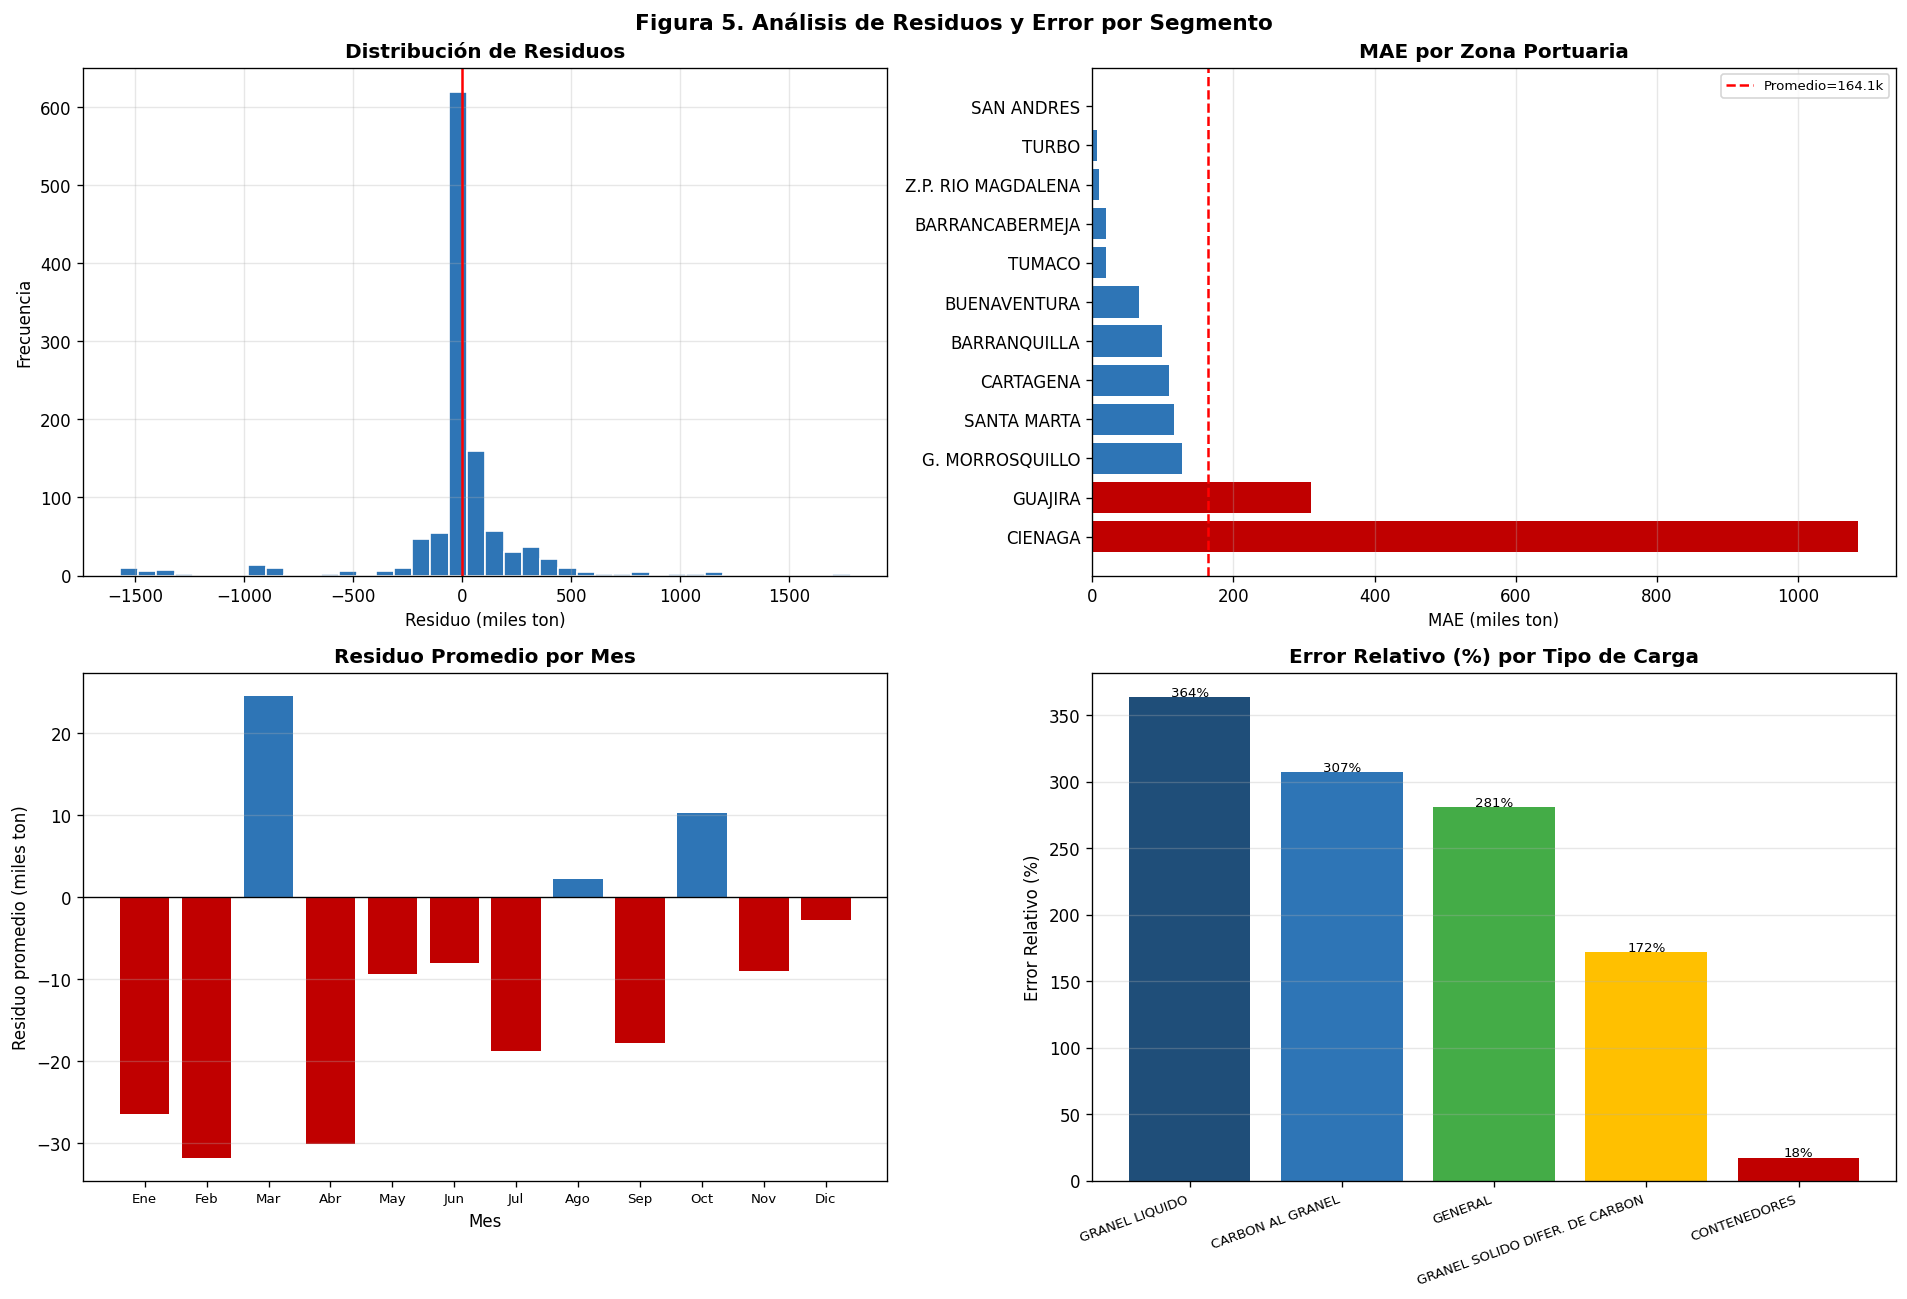

Figura 5 guardada.


In [13]:
test2['RESIDUO'] = test2['TOTAL_MOVILIZADO'] - test2['PRED']

fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle('Figura 5. Análisis de Residuos y Error por Segmento', fontsize=13, fontweight='bold')

# 5a: Histograma residuos
axes[0,0].hist(test2['RESIDUO']/1e3, bins=40, color='#2e75b6', edgecolor='white')
axes[0,0].axvline(0, color='red', linewidth=1.5)
axes[0,0].set_title('Distribución de Residuos', fontweight='bold')
axes[0,0].set_xlabel('Residuo (miles ton)'); axes[0,0].set_ylabel('Frecuencia')
axes[0,0].grid(alpha=0.3)

# 5b: MAE por zona
err_zona = test2.groupby('ZONA PORTUARIA')['RESIDUO'].apply(lambda x: np.abs(x).mean()).sort_values(ascending=False) / 1e3
promedio = err_zona.mean()
colores_z = ['#c00000' if v > promedio else '#2e75b6' for v in err_zona.values]
axes[0,1].barh(err_zona.index, err_zona.values, color=colores_z)
axes[0,1].axvline(promedio, color='red', linestyle='--', label=f'Promedio={promedio:.1f}k')
axes[0,1].set_title('MAE por Zona Portuaria', fontweight='bold')
axes[0,1].set_xlabel('MAE (miles ton)')
axes[0,1].legend(fontsize=8); axes[0,1].grid(axis='x', alpha=0.3)

# 5c: Residuo promedio por mes
err_mes = test2.groupby('MES VIGENCIA')['RESIDUO'].mean() / 1e3
cols_mes = ['#2e75b6' if v >= 0 else '#c00000' for v in err_mes.values]
axes[1,0].bar(err_mes.index, err_mes.values, color=cols_mes)
axes[1,0].axhline(0, color='black', linewidth=0.8)
axes[1,0].set_title('Residuo Promedio por Mes', fontweight='bold')
axes[1,0].set_xlabel('Mes'); axes[1,0].set_ylabel('Residuo promedio (miles ton)')
axes[1,0].set_xticks(range(1,13))
axes[1,0].set_xticklabels(['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic'], fontsize=8)
axes[1,0].grid(axis='y', alpha=0.3)

# 5d: Error relativo por tipo de carga
err_carga = test2.groupby('TIPO DE CARGA').apply(
    lambda x: (np.abs(x['RESIDUO']) / (x['TOTAL_MOVILIZADO'] + 1)).mean() * 100
).sort_values(ascending=False)
COLS = ['#1f4e79','#2e75b6','#44ac47','#ffc000','#c00000']
bars = axes[1,1].bar(range(len(err_carga)), err_carga.values, color=COLS[:len(err_carga)])
axes[1,1].set_xticks(range(len(err_carga)))
axes[1,1].set_xticklabels(err_carga.index, rotation=20, ha='right', fontsize=8)
axes[1,1].set_title('Error Relativo (%) por Tipo de Carga', fontweight='bold')
axes[1,1].set_ylabel('Error Relativo (%)')
for i, v in enumerate(err_carga.values):
    axes[1,1].text(i, v + 0.5, f'{v:.0f}%', ha='center', fontsize=8)
axes[1,1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('figura5_residuos_error.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura 5 guardada.')

## 9. Hallazgos propios

In [14]:
print('=== HALLAZGO 1 — Concentración portuaria dinámica ===')
for yr, hhi in zip(anos, hhi_vals):
    s = df[df['AÑO VIGENCIA']==yr].groupby('ZONA PORTUARIA')['TOTAL_MOVILIZADO'].sum()
    top3 = s.sort_values(ascending=False).head(3).sum() / s.sum() * 100
    print(f'  {yr}: HHI={hhi:.3f} | Top 3 zonas = {top3:.1f}%')

print()
print('=== HALLAZGO 2 — Error relativo mayor en zonas pequeñas ===')
err_rel_zona = test2.groupby('ZONA PORTUARIA').apply(
    lambda x: (np.abs(x['RESIDUO']) / (x['TOTAL_MOVILIZADO'] + 1)).mean() * 100
).sort_values(ascending=False)
print(err_rel_zona.round(1).to_string())

print()
print('=== HALLAZGO 3 — 2026 incompleto distorsiona la tendencia ===')
tot_sin = df[df['AÑO VIGENCIA'] < 2026]['TOTAL_MOVILIZADO'].sum()
tot_26  = df[df['AÑO VIGENCIA'] == 2026]['TOTAL_MOVILIZADO'].sum()
meses_26 = df[df['AÑO VIGENCIA'] == 2026]['MES VIGENCIA'].nunique()
prom_mensual_26 = tot_26 / meses_26
prom_mensual_25 = df[df['AÑO VIGENCIA'] == 2025]['TOTAL_MOVILIZADO'].sum() / 12
print(f'  2026 tiene solo {meses_26} meses → total acumulado: {tot_26/1e6:.1f}M ton')
print(f'  Promedio mensual 2026: {prom_mensual_26/1e6:.1f}M ton/mes')
print(f'  Promedio mensual 2025: {prom_mensual_25/1e6:.1f}M ton/mes')
print(f'  → No hay caída real, solo año incompleto.')

=== HALLAZGO 1 — Concentración portuaria dinámica ===
  2018: HHI=0.163 | Top 3 zonas = 58.6%
  2019: HHI=0.168 | Top 3 zonas = 61.7%
  2020: HHI=0.178 | Top 3 zonas = 66.8%
  2021: HHI=0.166 | Top 3 zonas = 59.9%
  2022: HHI=0.160 | Top 3 zonas = 59.6%
  2023: HHI=0.165 | Top 3 zonas = 59.8%
  2024: HHI=0.169 | Top 3 zonas = 60.2%
  2025: HHI=0.171 | Top 3 zonas = 59.5%

=== HALLAZGO 2 — Error relativo mayor en zonas pequeñas ===
ZONA PORTUARIA
TUMACO                2968.3
BARRANCABERMEJA        550.9
CIENAGA                465.2
GUAJIRA                381.7
BARRANQUILLA           353.7
SANTA MARTA            341.4
CARTAGENA              234.5
Z.P. RIO MAGDALENA     126.5
G. MORROSQUILLO         42.4
SAN ANDRES              35.0
BUENAVENTURA            31.9
TURBO                   15.8

=== HALLAZGO 3 — 2026 incompleto distorsiona la tendencia ===
  2026 tiene solo 3 meses → total acumulado: 39.6M ton
  Promedio mensual 2026: 13.2M ton/mes
  Promedio mensual 2025: 14.6M ton/mes
  → No

## 10. Sobreajuste — comparación train vs test

In [15]:
print('=== SOBREAJUSTE — Modelo Base M0 ===')
print(f'  MAE Train : {MAE0_tr/1e3:.1f}k ton')
print(f'  MAE Test  : {MAE0/1e3:.1f}k ton')
print(f'  Diferencia: {(MAE0 - MAE0_tr)/MAE0_tr*100:.1f}%  → sin sobreajuste significativo')
print(f'  R² Train  : {R2_0_tr:.3f}')
print(f'  R² Test   : {R2_0:.3f}')

=== SOBREAJUSTE — Modelo Base M0 ===
  MAE Train : 130.7k ton
  MAE Test  : 142.0k ton
  Diferencia: 8.7%  → sin sobreajuste significativo
  R² Train  : 0.727
  R² Test   : 0.692


## 11. Decisión ingenieril

In [16]:
print("""
DECISIÓN INGENIERIL
===================
Modelo recomendado: M0 — Media histórica por Zona × Tipo de Carga

Razón: supera a todos los modelos de regresión en MAE, RMSE y R².
La variabilidad del dataset no es capturada por tendencias lineales.

Condiciones de uso:
- Aplicar solo para zonas de alto volumen (Cartagena, Ciénaga,
  G. Morrosquillo, Buenaventura, Guajira, Barranquilla, Santa Marta).
- Para zonas pequeñas (Tumaco, San Andrés, Barrancabermeja): usar
  alertas por desviación del histórico, no predicciones puntuales.
- Recalibrar cada 6 meses con datos nuevos.
- Excluir años incompletos del recálculo de medias.
- Monitorear HHI anualmente: si supera 0.18, revisar estrategia.

Nivel de confianza: MEDIO (R²=0.692 en validación temporal).
""")


DECISIÓN INGENIERIL
Modelo recomendado: M0 — Media histórica por Zona × Tipo de Carga

Razón: supera a todos los modelos de regresión en MAE, RMSE y R².
La variabilidad del dataset no es capturada por tendencias lineales.

Condiciones de uso:
- Aplicar solo para zonas de alto volumen (Cartagena, Ciénaga,
  G. Morrosquillo, Buenaventura, Guajira, Barranquilla, Santa Marta).
- Para zonas pequeñas (Tumaco, San Andrés, Barrancabermeja): usar
  alertas por desviación del histórico, no predicciones puntuales.
- Recalibrar cada 6 meses con datos nuevos.
- Excluir años incompletos del recálculo de medias.
- Monitorear HHI anualmente: si supera 0.18, revisar estrategia.

Nivel de confianza: MEDIO (R²=0.692 en validación temporal).



## 12. Bitácora de uso de IA

In [17]:
bitacora = pd.DataFrame({
    'Fecha': ['Mayo 2026', 'Mayo 2026', 'Mayo 2026'],
    'Herramienta': ['Claude (Anthropic)', 'Claude (Anthropic)', 'Claude (Anthropic)'],
    'Para qué': [
        'Revisar estructura del informe contra la rúbrica',
        'Sugerir variables derivadas y codificación cíclica del mes',
        'Revisión de redacción de hallazgos'
    ],
    'Verificación': [
        'Verificado punto a punto contra documento del examen',
        'Implementado y verificado en Python',
        'Contrastado con resultados numéricos del notebook'
    ],
    'Confianza': ['5/5', '4/5', '5/5']
})
print('Bitácora de uso de IA:')
bitacora

Bitácora de uso de IA:


,Fecha,Herramienta,Para qué,Verificación,Confianza
0,Mayo 2026,Claude (Anthropic),Revisar estructura del informe contra la rúbrica,Verificado punto a punto contra documento del ...,5/5
1,Mayo 2026,Claude (Anthropic),Sugerir variables derivadas y codificación cíc...,Implementado y verificado en Python,4/5
2,Mayo 2026,Claude (Anthropic),Revisión de redacción de hallazgos,Contrastado con resultados numéricos del notebook,5/5


In [18]:
print('=== ANÁLISIS COMPLETADO ===')
print('Archivos generados:')
print('  figura1_calidad_datos.png')
print('  figura2_serie_temporal.png')
print('  figura3_comparacion_grupos.png')
print('  figura4_observado_predicho.png')
print('  figura5_residuos_error.png')
print('  metricas_modelos.csv')

=== ANÁLISIS COMPLETADO ===
Archivos generados:
  figura1_calidad_datos.png
  figura2_serie_temporal.png
  figura3_comparacion_grupos.png
  figura4_observado_predicho.png
  figura5_residuos_error.png
  metricas_modelos.csv
